## Análisis exploratorio (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/streaming_users_clean.csv', parse_dates=['last_login_date'])
print(df.shape)
df.head()

(8000, 9)


,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets,dias_desde_login
0,11451,45,Básico,632.7,Colombia,Documental,NaT,0,NaN
1,11587,39,Básico,534.0,Brasil,Comedia,NaT,0,NaN
2,12932,34,Básico,192.8,Chile,Romance,NaT,0,NaN
3,13034,13,Básico,123.9,Brasil,Romance,NaT,0,NaN
4,15230,26,Básico,895.7,Uruguay,Romance,NaT,0,NaN


#### Univariado

count    8000.00
mean      793.58
std       487.81
min         0.00
25%       499.15
50%       757.50
75%      1029.00
max      4193.70
Name: monthly_watch_time_mins, dtype: float64


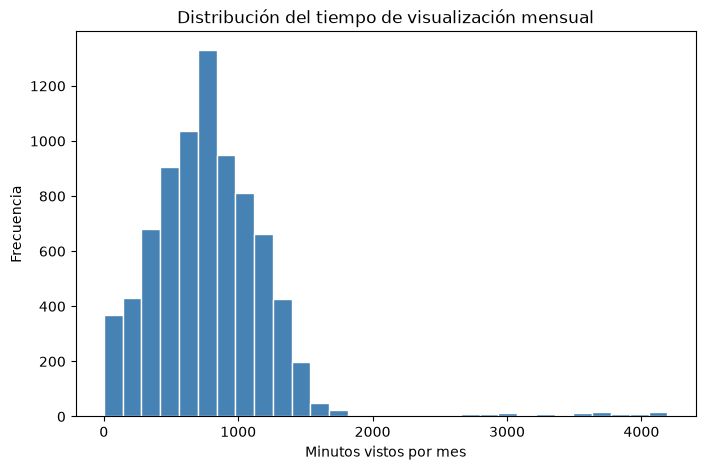

In [2]:
print(df['monthly_watch_time_mins'].describe().round(2))

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df['monthly_watch_time_mins'], bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Minutos vistos por mes')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del tiempo de visualización mensual')

plt.show()

La barra sobre-representada en torno a la mediana corresponde en parte a los valores imputados, no a una concentración real

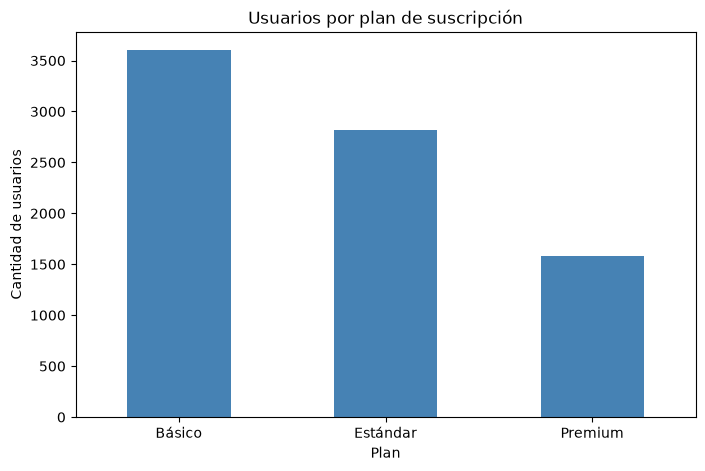

subscription_plan
Básico      45.0
Estándar    35.2
Premium     19.8
Name: proportion, dtype: float64


In [3]:
fig, ax = plt.subplots(figsize=(8,5))
df['subscription_plan'].value_counts().plot(kind='bar', color='steelblue', ax=ax)
ax.set_xlabel('Plan'); ax.set_ylabel('Cantidad de usuarios')
ax.set_title('Usuarios por plan de suscripción')
plt.xticks(rotation=0)

plt.show()

print(df['subscription_plan'].value_counts(normalize=True).mul(100).round(1))

El plan Básico concentra la mayoría de los usuarios y Premium es el que menos tiene. La mayoría prefiere pagar menos o le alcanza con los beneficios del plan
básico. (Básico 45%, Estándar 35.2%, Premium 19.8%)

### Bivariado

#### El tiempo de visualización difiere entre planes?

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23076\4285143653.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins',


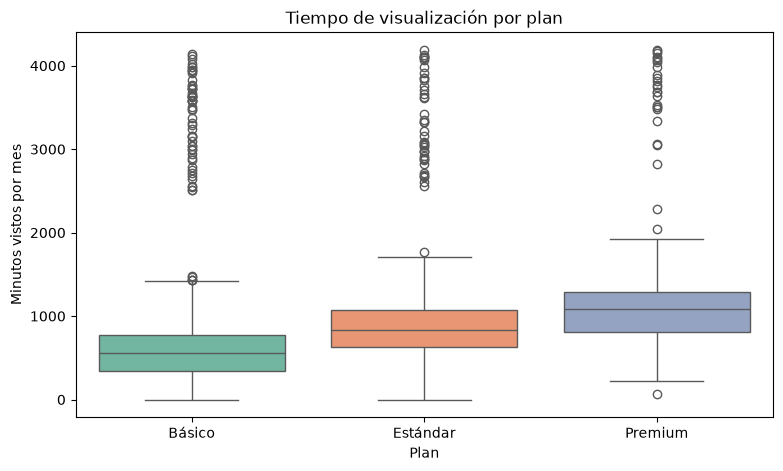

                     mean  median  count
subscription_plan                       
Básico              599.2   557.6   3600
Estándar            869.8   832.6   2817
Premium            1099.9  1081.1   1583


In [4]:
fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins',
            order=['Básico','Estándar','Premium'], palette='Set2', ax=ax)
ax.set_xlabel('Plan'); ax.set_ylabel('Minutos vistos por mes')
ax.set_title('Tiempo de visualización por plan')


plt.show()

# el número que respalda el graáfico
print(df.groupby('subscription_plan')['monthly_watch_time_mins']
        .agg(['mean','median','count']).round(1))

Aunque Básico agrupa la mayoría de los usuarios, el plan Premium muestra la mediana de minutos vistos por usuario más alta (Premium = 1081.1, Estándar = 832.6,
Básico = 557.6). 

Es decir: no es que Premium acumule más minutos en total, sino que cada usuario Premium consume más. Esto sugiere que quienes pagan el plan más caro efectivamente lo aprovechan más, lo que respalda la propuesta de valor del plan.

#### La inactividad (días sin login) se relaciona con el consumo?

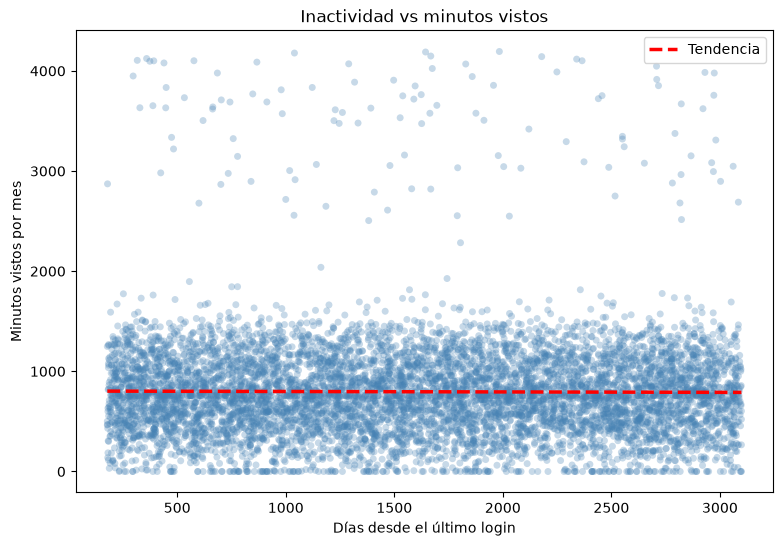

Correlación de Pearson: -0.0074
Usuarios incluidos (sin NaN): 7528 de 8000


In [5]:
x, y = 'dias_desde_login', 'monthly_watch_time_mins'

# dias_desde_login tiene NaN (usuarios sin fecha de login); los excluyo solo para este gráfico
sub = df[[x, y]].dropna()

plt.figure(figsize=(9,6))
plt.scatter(sub[x], sub[y], alpha=0.3, s=25, color='steelblue', edgecolors='none')
z = np.polyfit(sub[x], sub[y], 1); p = np.poly1d(z)
xs = np.linspace(sub[x].min(), sub[x].max(), 100)
plt.plot(xs, p(xs), 'r--', linewidth=2.5, label='Tendencia')
plt.xlabel('Días desde el último login'); plt.ylabel('Minutos vistos por mes')
plt.legend(); plt.title('Inactividad vs minutos vistos')

plt.show()

print(f"Correlación de Pearson: {sub[x].corr(sub[y]):.4f}")
print(f"Usuarios incluidos (sin NaN): {len(sub)} de {len(df)}")

La correlación entre los días desde el último login y los minutos vistos prácticamente nula. El signo negativo coincide con la hipótesis (más
inactividad, menos consumo), pero la magnitud es tan baja que no constituye evidencia de relación.

La única relación clara es **plan → consumo** (a mayor plan, más minutos vistos). 
La inactividad (días sin login) no muestra asociación con el consumo, y la edad se 
analiza en el gráfico multivariado. El comportamiento del usuario depende casi solo 
del plan contratado.

### Multivariado

#### Consumo según edad y plan

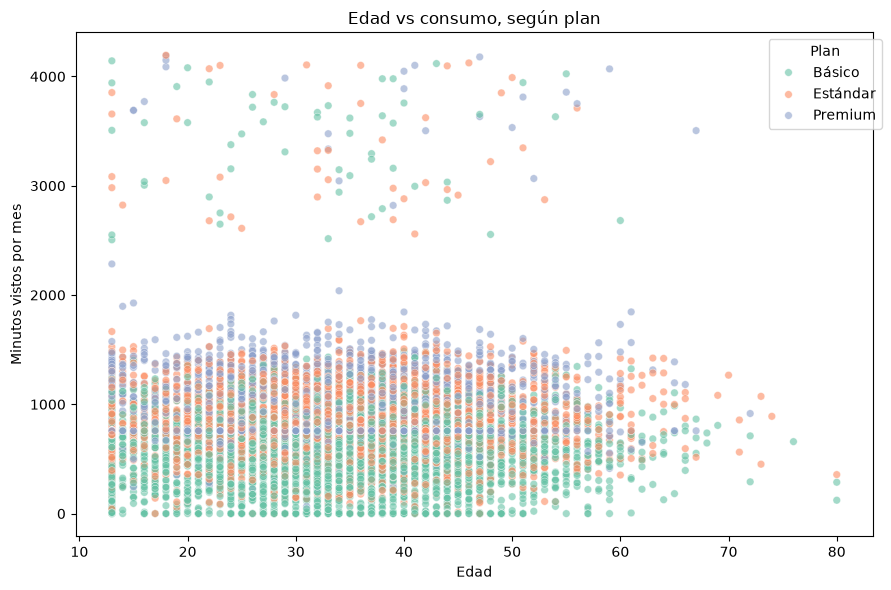

In [6]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='age', y='monthly_watch_time_mins',
                hue='subscription_plan', hue_order=['Básico','Estándar','Premium'],
                palette='Set2', alpha=0.6, s=30)
plt.xlabel('Edad'); plt.ylabel('Minutos vistos por mes')
plt.title('Edad vs consumo, según plan')
plt.legend(title='Plan', bbox_to_anchor=(1.02, 1))
plt.tight_layout()


plt.show()

Los usuarios Básico se ubican en la franja inferior de consumo y los Premium en la superior. La diferencia entre planes se mantiene a todas las edades.

No se observa paradoja de Simpson: la relación plan–consumo se mantiene en todos los tramos de edad.